# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Michael Valent Satrio Munthe
- **Email:** cdcc319d6y0756@student.devacademy.id

- **ID Dicoding:** CDCC319D6Y0756

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh berbagai musim (season) terhadap jumlah total penyewaan sepeda (cnt) secara keseluruhan selama tahun 2011 hingga 2012?

- Specific: Fokus melihat hubungan antara musim dan total penyewaan.

- Measurable: Dapat dihitung jelas menggunakan metrik jumlah total penyewa (cnt).

- Action-Oriented: Insight ini bisa digunakan pengelola bisnis untuk mengalokasikan unit sepeda lebih banyak di musim ramai dan menjadwalkan perawatan rutin di musim sepi.

- Relevant: Sangat relevan dengan optimalisasi pendapatan bisnis penyewaan sepeda.

- Time-bound: Dibatasi pada rentang data observasi yaitu tahun 2011-2012.
- **Pertanyaan 2:** Bagaimana perbandingan perilaku penyewaan sepeda antara pengguna kasual (casual) dan pengguna terdaftar (registered) pada hari kerja (workingday) versus hari libur/akhir pekan selama tahun 2011-2012?

- Specific: Membandingkan dua tipe pelanggan (casual vs registered) berdasarkan tipe hari (hari kerja vs libur).

- Measurable: Bisa dihitung dengan membandingkan jumlah kolom casual dan registered yang dikelompokkan berdasarkan kolom workingday.

- Action-Oriented: Jika pengguna casual membeludak di hari libur, bisnis bisa membuat promo akhir pekan khusus untuk mengubah mereka menjadi member registered.

- Relevant: Relevan dengan strategi marketing dan retensi pelanggan.

- Time-bound: Dibatasi pada rentang tahun 2011-2012.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur style visualisasi seaborn
sns.set_theme(style="darkgrid")

## Data Wrangling

### Gathering Data

#### Load dataset day dan hour

In [4]:
# Memuat data day.csv
day_df = pd.read_csv("day.csv")

# Memuat data hour.csv
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari day_df untuk memastikan data berhasil dimuat
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Dataset telah berhasil dimuat menjadi dua DataFrame: `day_df` (menyimpan data agregasi harian) dan `hour_df` (menyimpan data agregasi per jam).
- Berdasarkan pengamatan awal pada `day_df.head()`, dataset ini memuat informasi terkait kondisi lingkungan (seperti musim, cuaca, suhu, kelembapan) dan jumlah penyewaan sepeda yang terbagi menjadi pengguna kasual dan pengguna terdaftar (member).
- Kolom-kolom di dalam dataset sudah terstruktur dengan baik, namun beberapa kolom seperti tanggal dan musim memerlukan pemeriksaan lebih lanjut terkait format dan tipe datanya.

### Assessing Data

#### Identifying data problem
1. **Invalid/Inappropriate Data Type**: Tipe data pada kolom dteday (tanggal) di kedua DataFrame terbaca sebagai object (string). Padahal, agar bisa dianalisis berdasarkan waktu, tipe datanya harus berupa datetime.

2. **Inconsistent/Unreadable Value (Categorical Encoding)**: Beberapa kolom kategorik seperti season, yr, mnth, weathersit, dan weekday masih menggunakan angka (integer). Misalnya, season bernilai 1, 2, 3, 4. Ini akan menyulitkan saat membuat visualisasi. Angka ini perlu diubah menjadi keterangan teks yang jelas (misal: 1 = Springer, 2 = Summer, dst).

In [5]:
# Memeriksa tipe data dan missing value pada day_df
print("Info day_df:")
day_df.info()

print("\nJumlah missing value day_df:")
print(day_df.isna().sum())

print("\nInfo hour_df:")
hour_df.info()

Info day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah missing value day_df:
instant       0
dteday        0
season        0
yr

In [6]:
# Memeriksa duplikasi data
print("Jumlah duplikasi day_df: ", day_df.duplicated().sum())
print("Jumlah duplikasi hour_df: ", hour_df.duplicated().sum())

# Memeriksa ringkasan statistik
day_df.describe()

Jumlah duplikasi day_df:  0
Jumlah duplikasi hour_df:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengubah tipe data kolom dteday menjadi datetime.
- Memetakan ulang (mapping) nilai angka pada kolom kategorik menjadi string/label yang mudah dipahami (Mapping nilai season, yr, mnth, weathersit, dan weekday).

**Insight:** (Opsional)
- Secara keseluruhan, dataset ini sangat bersih. Tidak ditemukan adanya *missing value* (nilai kosong) maupun *duplicate data* (data ganda) pada kedua DataFrame (`day_df` dan `hour_df`).
- Namun, ditemukan isu terkait representasi data. Tipe data pada kolom `dteday` masih berupa `object` (string), padahal seharusnya berupa format `datetime` untuk mempermudah analisis *time-series*.
- Selain itu, nilai pada kolom kategorik (seperti `season`, `yr`, `mnth`, `weathersit`, dan `weekday`) masih disandikan dalam bentuk angka bulat (integer). Hal ini mengurangi tingkat keterbacaan data dan dapat menyulitkan interpretasi saat membuat visualisasi nanti.

### Cleaning Data

#### Mengubah tipe data dteday menjadi datetime

In [7]:
# Mengubah tipe data kolom dteday menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

print("Tipe data dteday pada day_df:", day_df["dteday"].dtypes)

Tipe data dteday pada day_df: datetime64[ns]


#### Memetakan nilai angka pada kolom kategorik menjadi label teks

In [8]:
# Mengubah tipe data angka menjadi label string yang mudah dibaca pada day_df
# Sesuai dengan keterangan di Readme.txt

season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season'] = day_df['season'].map(season_mapping)

year_mapping = {0: 2011, 1: 2012}
day_df['yr'] = day_df['yr'].map(year_mapping)

month_mapping = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
day_df['mnth'] = day_df['mnth'].map(month_mapping)

weekday_mapping = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
                   4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
day_df['weekday'] = day_df['weekday'].map(weekday_mapping)

weather_mapping = {1: 'Clear/Partly Cloudy', 2: 'Mist/Cloudy',
                   3: 'Light Snow/Rain', 4: 'Severe Weather'}
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)

# Mengecek hasil mapping
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,Jan,0,Saturday,0,Mist/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,Jan,0,Sunday,0,Mist/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,Jan,0,Monday,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,Jan,0,Tuesday,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,Jan,0,Wednesday,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Tipe data pada kolom `dteday` telah berhasil diubah menjadi format `datetime64[ns]`. Ini akan memungkinkan kita untuk melakukan ekstraksi atau agregasi data berbasis waktu (time-series) dengan lebih mudah ke depannya.
- Kolom-kolom kategorik (seperti `season`, `yr`, `mnth`, `weekday`, dan `weathersit`) telah berhasil diubah dari kode angka menjadi label teks yang deskriptif. Transformasi ini akan membuat visualisasi data di tahap selanjutnya menjadi jauh lebih informatif dan mudah dipahami oleh audiens.

## Exploratory Data Analysis (EDA)

### Eksplorasi parameter penyewaan sepeda berdasarkan musim (season)

In [9]:
# Melihat ringkasan jumlah penyewaan sepeda (cnt) berdasarkan musim
day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "sum"]
}).sort_values(by=("cnt", "sum"), ascending=False)

cnt                            
         max   min         mean      sum
season                                  
Fall    8714  1115  5644.303191  1061129
Summer  8362   795  4992.331522   918589
Winter  8555    22  4728.162921   841613
Spring  7836   431  2604.132597   471348

### Eksplorasi perilaku pengguna (casual vs registered) berdasarkan hari kerja (workingday)

In [10]:
# Memetakan nilai workingday agar lebih mudah dibaca (0 = Holiday/Weekend, 1 = Working Day)
workingday_mapping = {0: 'Holiday/Weekend', 1: 'Working Day'}
day_df['workingday'] = day_df['workingday'].map(workingday_mapping)

# Mengelompokkan total pengguna casual dan registered berdasarkan tipe hari
day_df.groupby(by="workingday").agg({
    "casual": "sum",
    "registered": "sum",
    "cnt": "sum"
}).reset_index()

,workingday,casual,registered,cnt
0,Holiday/Weekend,316732,683537,1000269
1,Working Day,303285,1989125,2292410


**Insight:** (Opsional)
- **Berdasarkan Musim:** Dari hasil agregasi, terlihat bahwa musim gugur (*Fall*) adalah musim dengan jumlah penyewaan sepeda tertinggi secara keseluruhan, disusul oleh musim panas (*Summer*). Sebaliknya, musim semi (*Spring*) memiliki jumlah penyewaan terendah. Rata-rata penyewaan di musim gugur juga jauh lebih tinggi dibandingkan musim lainnya.
- **Berdasarkan Hari Kerja:** Pengguna terdaftar (*registered*) mendominasi jumlah penyewaan secara keseluruhan, baik di hari kerja maupun hari libur. Namun, ada tren menarik pada pengguna *casual*. Jumlah penyewaan oleh pengguna *casual* justru lebih tinggi pada hari libur/akhir pekan (*Holiday/Weekend*) dibandingkan pada hari kerja (*Working Day*), yang menunjukkan bahwa mereka kemungkinan menyewa sepeda untuk rekreasi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_1130/3976457713.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


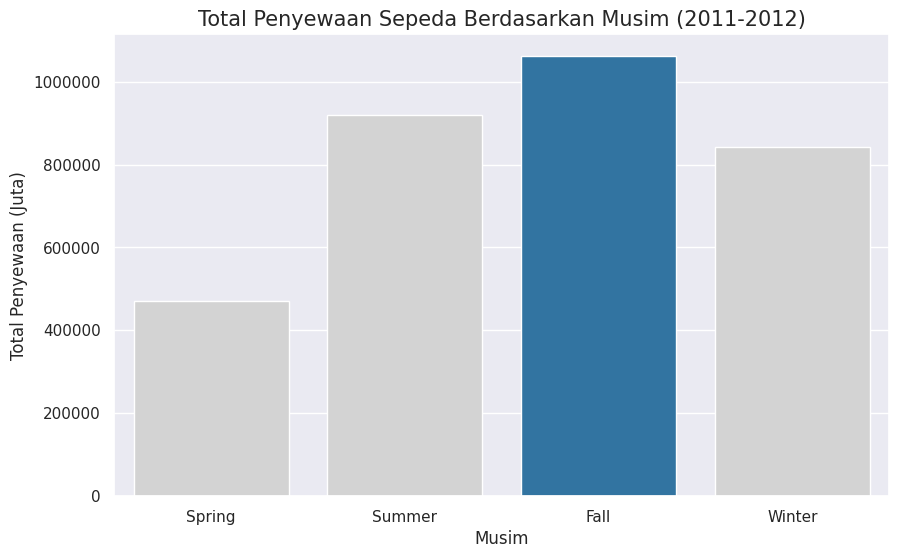

In [11]:
plt.figure(figsize=(10, 6))

# Membuat bar chart untuk total penyewaan per musim
sns.barplot(
    y="cnt",
    x="season",
    data=day_df,
    estimator=sum,
    order=["Spring", "Summer", "Fall", "Winter"],
    errorbar=None,
    palette=["#D3D3D3", "#D3D3D3", "#1f77b4", "#D3D3D3"] # Meng-highlight musim Fall (tertinggi)
)

plt.title("Total Penyewaan Sepeda Berdasarkan Musim (2011-2012)", loc="center", fontsize=15)
plt.ylabel("Total Penyewaan (Juta)")
plt.xlabel("Musim")
plt.ticklabel_format(style='plain', axis='y') # Menghilangkan format scientific (e) pada sumbu y
plt.show()

### Pertanyaan 2:

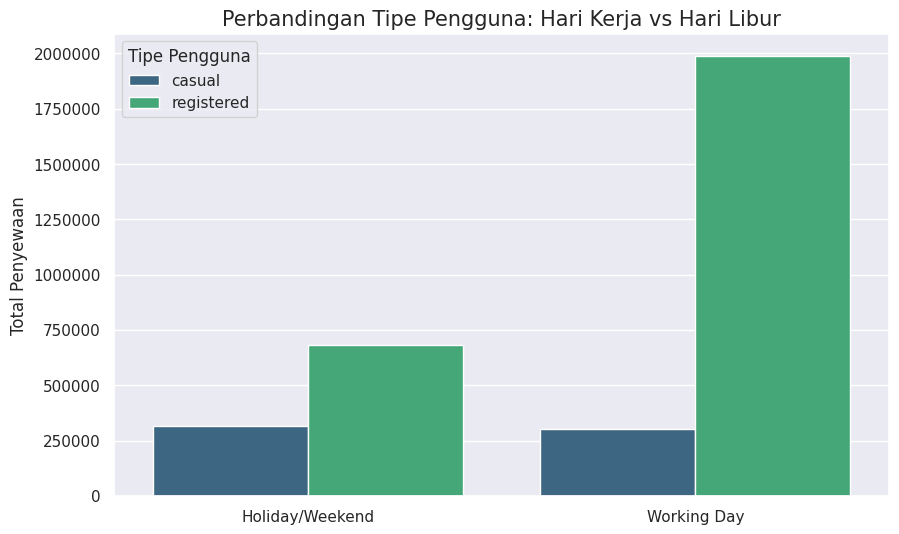

In [12]:
plt.figure(figsize=(10, 6))

# Mengubah format data (melt) agar mudah dibuat grouped bar chart
melt_df = day_df.melt(id_vars='workingday', value_vars=['casual', 'registered'],
                      var_name='user_type', value_name='total_rentals')

# Membuat grouped bar chart
sns.barplot(
    x='workingday',
    y='total_rentals',
    hue='user_type',
    data=melt_df,
    estimator=sum,
    errorbar=None,
    palette="viridis"
)

plt.title("Perbandingan Tipe Pengguna: Hari Kerja vs Hari Libur", loc="center", fontsize=15)
plt.ylabel("Total Penyewaan")
plt.xlabel(None)
plt.legend(title="Tipe Pengguna")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight:** (Opsional)
- **Visualisasi 1:** Grafik batang dengan jelas menunjukkan bahwa "Fall" (Musim Gugur) adalah puncak penyewaan sepeda (highlight biru), mencapai lebih dari 1 juta penyewaan selama 2 tahun. Sementara "Spring" (Musim Semi) merupakan musim dengan performa terendah.
- **Visualisasi 2:** Grafik perbandingan ini mengonfirmasi temuan agregasi kita. Pengguna *Registered* selalu mendominasi, terutama di hari kerja (diduga untuk *commuting* atau berangkat kerja/sekolah). Sebaliknya, batang pengguna *Casual* mengalami peningkatan yang terlihat jelas pada "Holiday/Weekend" dibandingkan hari kerja, menandakan tipe pengguna ini lebih banyak menyewa sepeda untuk rekreasi di waktu luang.

## Analisis Lanjutan: Clustering (Binning) Kategori Suhu (Temperature)

/tmp/ipykernel_1130/9086961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='temp_cluster', y='cnt', data=cluster_df, palette='Oranges')


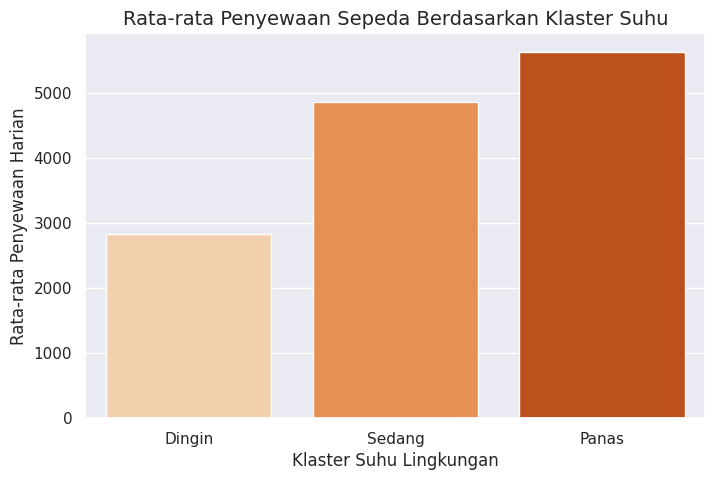

In [13]:
# Berdasarkan Readme.txt, nilai kolom 'temp' sudah dinormalisasi.
# Kita kalikan 41 untuk mengembalikan nilainya ke dalam skala Celcius yang mudah dipahami.
day_df['temp_celcius'] = day_df['temp'] * 41

# Menentukan batas interval (bins) dan label untuk klasterisasi (binning)
bins = [0, 15, 25, 45] # Dingin (<15°C), Sedang (15-25°C), Panas (>25°C)
labels = ['Dingin', 'Sedang', 'Panas']

# Menerapkan teknik binning untuk membuat kolom kategori baru
day_df['temp_cluster'] = pd.cut(day_df['temp_celcius'], bins=bins, labels=labels)

# Menghitung rata-rata penyewaan untuk masing-masing klaster suhu
cluster_df = day_df.groupby('temp_cluster', observed=False)['cnt'].mean().reset_index()

# Visualisasi hasil clustering
plt.figure(figsize=(8, 5))
sns.barplot(x='temp_cluster', y='cnt', data=cluster_df, palette='Oranges')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Klaster Suhu', fontsize=14)
plt.xlabel('Klaster Suhu Lingkungan')
plt.ylabel('Rata-rata Penyewaan Harian')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** - Musim (*season*) memiliki pengaruh yang sangat signifikan terhadap jumlah penyewaan sepeda. Musim gugur (*Fall*) mencetak rekor sebagai musim dengan total penyewaan tertinggi, disusul oleh musim panas (*Summer*). Sebaliknya, musim semi (*Spring*) mengalami tingkat penyewaan paling rendah. Hal ini menunjukkan pesepeda cenderung menghindari cuaca awal tahun yang mungkin masih terlalu dingin atau basah.
- **Conclusion pertanyaan 2:** - Terdapat pola perilaku yang sangat kontras antara pengguna *casual* dan *registered*. Pengguna terdaftar (*registered*) menggunakan sepeda secara stabil dan mendominasi di hari kerja (*working day*), yang mengindikasikan penggunaan sepeda untuk mobilitas rutin seperti bekerja atau bersekolah. Di sisi lain, pengguna kasual (*casual*) menunjukkan lonjakan penyewaan yang signifikan justru pada hari libur atau akhir pekan (*holiday/weekend*), yang kuat dugaan didorong oleh tujuan rekreasi dan olahraga santai.


**Rekomendasi Action Item:**
- **Optimalisasi Operasional (Maintenance):** Perusahaan sebaiknya menjadwalkan perbaikan dan perawatan besar-besaran armada sepeda pada saat Musim Semi (*Spring*) karena volume penyewaan sedang berada di titik terendah. Dengan begitu, armada berada dalam kondisi 100% prima untuk menghadapi lonjakan permintaan di Musim Panas dan Gugur.
- **Strategi Marketing (Konversi Pelanggan):** Karena tingginya minat pengguna *casual* di akhir pekan, tim *marketing* dapat meluncurkan promo "Weekend Explorer Pass" khusus di hari Sabtu/Minggu. Promo ini bisa disisipkan penawaran diskon khusus jika pengguna *casual* mendaftarkan diri menjadi *member (registered)*, sehingga dapat meningkatkan retensi pelanggan di masa depan.